In [1]:
%matplotlib inline
from matplotlib import style
style.use('fivethirtyeight')
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import datetime as dt
from pprint import pprint

# Reflect Tables into SQLAlchemy ORM

In [3]:
# Python SQL toolkit and Object Relational Mapper
import sqlalchemy
from sqlalchemy.ext.automap import automap_base
from sqlalchemy.orm import Session
from sqlalchemy import create_engine, func
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy import Column, Integer, String, Float
from sqlalchemy.types import Date

In [4]:
# set up Base

Base = declarative_base()


In [5]:
#create class for measurement table

class Measurement(Base):
    __tablename__ = "measurement"
    
    id = Column(Integer, primary_key=True)
    station = Column(String)
    date = Column(Date)
    prcp = Column(Float)
    tobs = Column(Float)

In [6]:
#create class for station table

class Station(Base):
    __tablename__ = "station"
    
    id = Column(Integer, primary_key=True)
    station = Column(String)
    name = Column(String)
    latitude = Column(Float)
    longitude = Column(Float)
    elevation =  Column(Float)

In [7]:
# create engine to hawaii.sqlite
engine = create_engine("sqlite:///Resources/hawaii.sqlite")
conn = engine.connect()
session = Session(bind=engine)


In [8]:
# reflect the database schema
Base = automap_base()
Base.prepare(engine, reflect=True)

# print all of the classes that automap found
print(Base.classes.keys())

['measurement', 'station']


# Exploratory Precipitation Analysis

In [9]:
#check the max date in data
max_date = session.query(func.max(Measurement.date)).first()[0]

print(max_date)

2017-08-23


In [10]:
# get the last 12 months of precipitation data

recent_prcp = session.query(Measurement.date, Measurement.prcp)\
    .filter(Measurement.date > '2016-08-23')\
    .filter(Measurement.date <= '2017-08-24')\
    .order_by(Measurement.date).all()
        
pprint(recent_prcp)

[(datetime.date(2016, 8, 24), 0.08),
 (datetime.date(2016, 8, 24), 2.15),
 (datetime.date(2016, 8, 24), 2.28),
 (datetime.date(2016, 8, 24), None),
 (datetime.date(2016, 8, 24), 1.22),
 (datetime.date(2016, 8, 24), 2.15),
 (datetime.date(2016, 8, 24), 1.45),
 (datetime.date(2016, 8, 25), 0.08),
 (datetime.date(2016, 8, 25), 0.08),
 (datetime.date(2016, 8, 25), 0.0),
 (datetime.date(2016, 8, 25), 0.0),
 (datetime.date(2016, 8, 25), 0.21),
 (datetime.date(2016, 8, 25), 0.06),
 (datetime.date(2016, 8, 25), 0.11),
 (datetime.date(2016, 8, 26), 0.0),
 (datetime.date(2016, 8, 26), 0.03),
 (datetime.date(2016, 8, 26), 0.02),
 (datetime.date(2016, 8, 26), 0.04),
 (datetime.date(2016, 8, 26), 0.0),
 (datetime.date(2016, 8, 26), 0.01),
 (datetime.date(2016, 8, 27), 0.0),
 (datetime.date(2016, 8, 27), 0.18),
 (datetime.date(2016, 8, 27), 0.02),
 (datetime.date(2016, 8, 27), 0.0),
 (datetime.date(2016, 8, 27), 0.12),
 (datetime.date(2016, 8, 27), None),
 (datetime.date(2016, 8, 28), 0.01),
 (datet

In [11]:
# load query results into a Pandas dataframe

prcp_df = pd.DataFrame(recent_prcp, columns = ["Date", "Precipitation"])

# set index to the date column

prcp_df.set_index("Date", inplace=True)

prcp_df

,Precipitation
Date,
2016-08-24,0.08
2016-08-24,2.15
2016-08-24,2.28
2016-08-24,NaN
2016-08-24,1.22
...,...
2017-08-22,0.50
2017-08-23,0.00
2017-08-23,0.00


In [12]:
# convert date column to datetime for formatting in plot

prcp_df.index = pd.to_datetime(prcp_df.index, format="%Y/%m/%d")

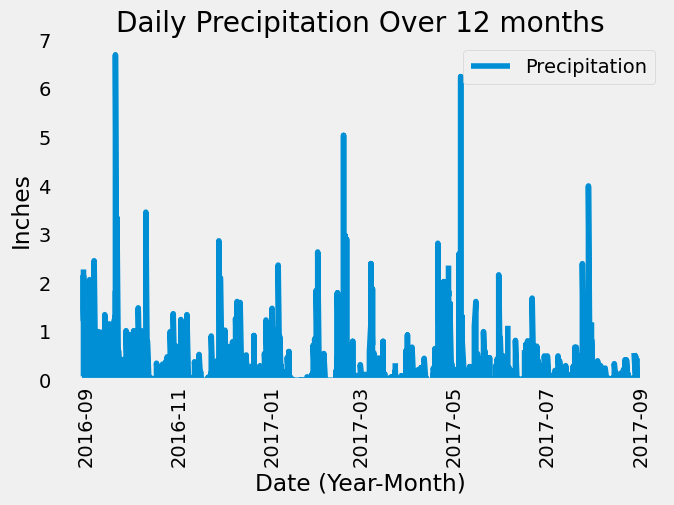

In [13]:
# plot precipitation results using Dataframe plot method

prcp_plot = prcp_df.plot(figsize=(7,5), ylim=(0,7), title = "Daily Precipitation Over 12 months", rot=90)
prcp_plot.set_ylabel("Inches")
prcp_plot.set_xlabel("Date (Year-Month)")
prcp_plot.grid()
plt.savefig("Images/precipitation.png")
plt.show()

In [14]:
# print a summary statistics table for the precipitation data
precipitation = prcp_df["Precipitation"].to_frame()
precipitation.describe()

,Precipitation
count,2015.000000
mean,0.176462
std,0.460288
min,0.000000
25%,0.000000
50%,0.020000
75%,0.130000
max,6.700000


# Exploratory Station Analysis

In [15]:
#calculate the total number of stations

total_stations = session.query(func.count(func.distinct(Measurement.station))).first()[0]
total_stations

9

In [16]:
#find the most active stations

active_stations = session.query(Measurement.station, func.count(Measurement.id))\
    .group_by(Measurement.station)\
    .order_by(func.count(Measurement.id).desc()).all()

active_stations

[('USC00519281', 2772),
 ('USC00519397', 2724),
 ('USC00513117', 2709),
 ('USC00519523', 2669),
 ('USC00516128', 2612),
 ('USC00514830', 2202),
 ('USC00511918', 1979),
 ('USC00517948', 1372),
 ('USC00518838', 511)]

In [17]:
# get the last 12 months of temperature observation data for station USC00519281

tobs_station = session.query(Measurement.station, Measurement.tobs)\
    .filter(Measurement.date > '2016-08-23')\
    .filter(Measurement.date <= '2017-08-23')\
    .filter(Measurement.station == "USC00519281").all()

tobs_station

[('USC00519281', 77.0),
 ('USC00519281', 80.0),
 ('USC00519281', 80.0),
 ('USC00519281', 75.0),
 ('USC00519281', 73.0),
 ('USC00519281', 78.0),
 ('USC00519281', 77.0),
 ('USC00519281', 78.0),
 ('USC00519281', 80.0),
 ('USC00519281', 80.0),
 ('USC00519281', 78.0),
 ('USC00519281', 78.0),
 ('USC00519281', 78.0),
 ('USC00519281', 73.0),
 ('USC00519281', 74.0),
 ('USC00519281', 80.0),
 ('USC00519281', 79.0),
 ('USC00519281', 77.0),
 ('USC00519281', 80.0),
 ('USC00519281', 76.0),
 ('USC00519281', 79.0),
 ('USC00519281', 75.0),
 ('USC00519281', 79.0),
 ('USC00519281', 78.0),
 ('USC00519281', 79.0),
 ('USC00519281', 78.0),
 ('USC00519281', 78.0),
 ('USC00519281', 76.0),
 ('USC00519281', 74.0),
 ('USC00519281', 77.0),
 ('USC00519281', 78.0),
 ('USC00519281', 79.0),
 ('USC00519281', 79.0),
 ('USC00519281', 77.0),
 ('USC00519281', 80.0),
 ('USC00519281', 78.0),
 ('USC00519281', 78.0),
 ('USC00519281', 78.0),
 ('USC00519281', 77.0),
 ('USC00519281', 79.0),
 ('USC00519281', 79.0),
 ('USC00519281',

In [18]:
# convert results to a dataframe for plotting
station_temp_df = pd.DataFrame(tobs_station, columns=["Station", "Temp. Observations"])
station_temp_df.head()

,Station,Temp. Observations
0,USC00519281,77.0
1,USC00519281,80.0
2,USC00519281,80.0
3,USC00519281,75.0
4,USC00519281,73.0


In [19]:
# Get the most active station ID from the previous query
most_active_station = active_stations[0][0]

# Query the minimum, maximum, and average temperature for the most active station
temp_stats = session.query(func.min(Measurement.tobs), func.max(Measurement.tobs), func.avg(Measurement.tobs))\
    .filter(Measurement.station == most_active_station).all()


# Extract the results
tmin, tmax, tavg = temp_stats[0]

# Print the results
print(f"Lowest temperature at station {most_active_station}: {tmin} degrees F")
print(f"Highest temperature at station {most_active_station}: {tmax} degrees F")
print(f"Average temperature at station {most_active_station}: {tavg} degrees F")



Lowest temperature at station USC00519281: 54.0 degrees F
Highest temperature at station USC00519281: 85.0 degrees F
Average temperature at station USC00519281: 71.66378066378067 degrees F


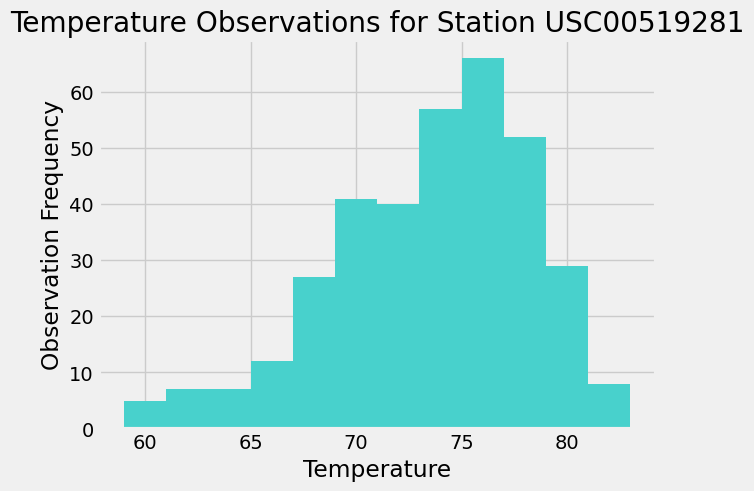

In [20]:
# plot a histogram of the results

station_temp_df["Temp. Observations"].hist(bins=12, color="mediumturquoise")
plt.title("Temperature Observations for Station USC00519281")
plt.xlabel("Temperature")
plt.ylabel("Observation Frequency")
plt.savefig("Images/histogram.png")
plt.show()

# Close Session

In [21]:
# Close Session
session.close()